# Laboratorio 1: Señales, Muestreo y Cuantificación
**Curso:** Teoría de la Información Transmisión de Datos

Este laboratorio tiene como objetivo explorar los conceptos fundamentales del procesamiento digital de señales que son clave para la teoría de la información y la transmisión de datos.

Se abordarán los siguientes temas:
* Señales sinusoidales discretas en el tiempo y su representación espectral mediante la Transformada Rápida de Fourier (FFT).
* Muestreo de señales analógicas y sus implicancias.
* Teorema de muestreo de Nyquist-Shannon.
* Cuantificación de señales continuas en amplitud y análisis del error de cuantificación.


## Configuración Inicial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.fftpack import fft, fftfreq
from scipy import signal

# Ajustes para gráficos
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

## Señales sinusoidales discretas
En esta sección se genera una señal sinusoidal discreta a partir de una señal continua de frecuencia $F = 50 \ \text{Hz}$, fase inicial $\theta = \pi/3 \ \text{rad}$ y frecuencia de muestreo $F_s = 600 \ \text{Hz}$.
El muestreo se realiza en un rango finito de índices $n$, obteniendo la secuencia $x[n]$ que representa los valores de la señal continua en los instantes de muestreo.

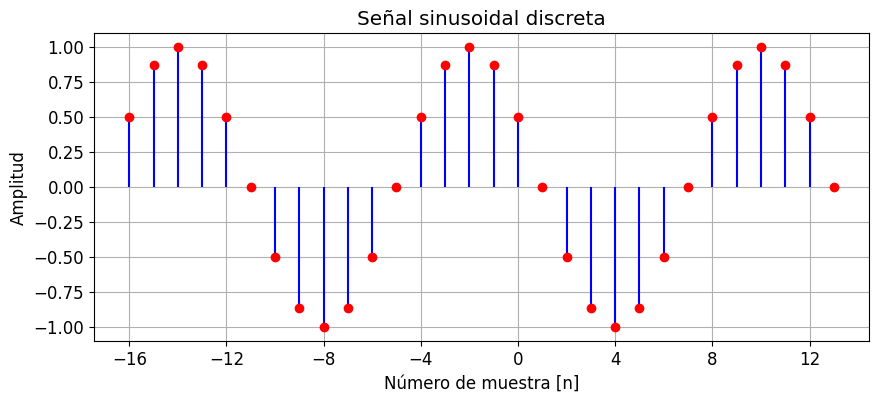

In [2]:
# Parámetros de la señal
Fs = 600        # Frecuencia de muestreo (Hz)
F = 50          # Frecuencia de la señal (Hz)
theta = np.pi/3 # Fase (rad)

n = np.arange(-16, 14)
x = np.cos(2*np.pi*F*n/Fs + theta)

# Visualización
fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(n, x, basefmt=" ")
plt.setp(markerline, marker='o', markersize=6, color='red')
plt.setp(stemlines, color='blue', linewidth=1.5)
plt.setp(baseline, visible=False)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title("Señal sinusoidal discreta")
plt.xlabel("Número de muestra [n]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

## Espectro de Frecuencia (FFT)
En esta sección se calcula la Transformada Rápida de Fourier (FFT) de la señal discreta, empleando un tamaño de transformada $N_{\mathrm{FFT}} = 12$.
A partir de la FFT se obtiene el espectro en frecuencia, calculando la magnitud normalizada y representando tanto las componentes de frecuencia positiva como negativa.

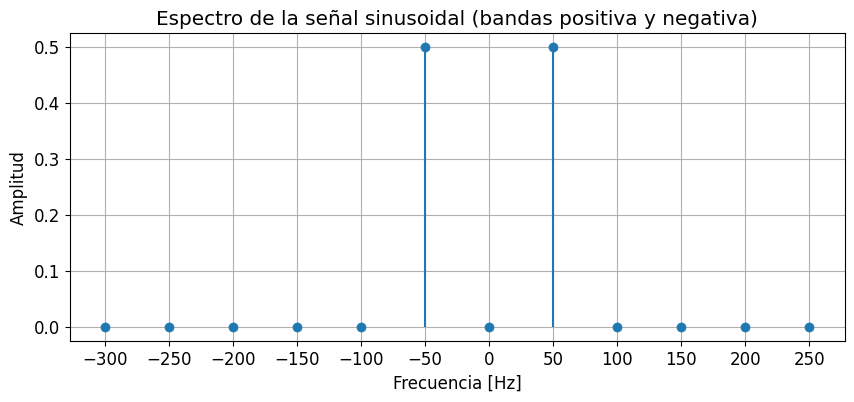

In [3]:
# FFT
Nfft = 12
X = fft(x, Nfft)
freqs = fftfreq(Nfft, 1/Fs)

# Magnitud normalizada correctamente
magnitude = np.abs(X) / Nfft

# Graficar dos bandas
plt.stem(freqs, magnitude, basefmt=" ")
plt.title("Espectro de la señal sinusoidal (bandas positiva y negativa)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.grid(True)

# Marcar frecuencias cada 50 Hz
min_f = int(np.floor(freqs.min() / 50.0) * 50)
max_f = int(np.ceil(freqs.max() / 50.0) * 50)
plt.xticks(np.arange(min_f, max_f + 50, 50))

plt.show()

# Ejercicio 1
Repita el procedimiento de generación, visualización y análisis espectral realizado en las secciones anteriores, pero considerando una señal sinusoidal de frecuencia $F = 1.25 \ \text{kHz}$ y fase inicial $\theta = \pi/3 \ \text{rad}$, manteniendo la misma frecuencia de muestreo $F_s = 600 \ \text{Hz}$.
Genere la señal discreta correspondiente, represéntela mediante un gráfico y obtenga su espectro de amplitud utilizando la Transformada Rápida de Fourier (FFT) con el mismo tamaño $N_{\mathrm{FFT}}$ empleado previamente. Finalmente, discuta los resultados obtenidos, haciendo especial énfasis en los efectos de aliasing observados.

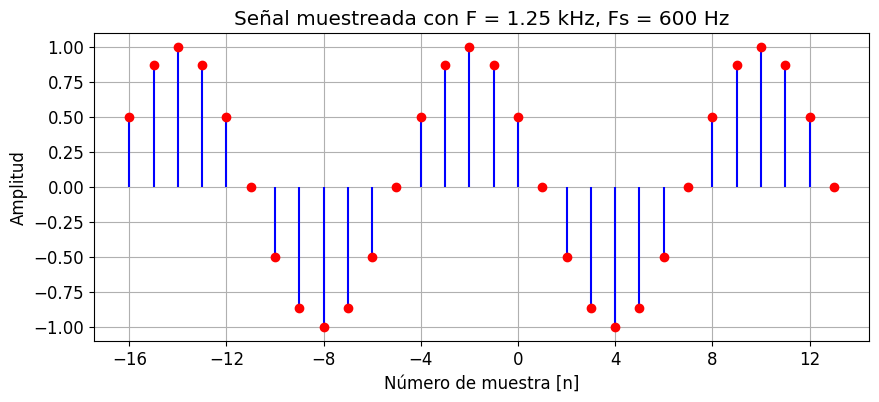

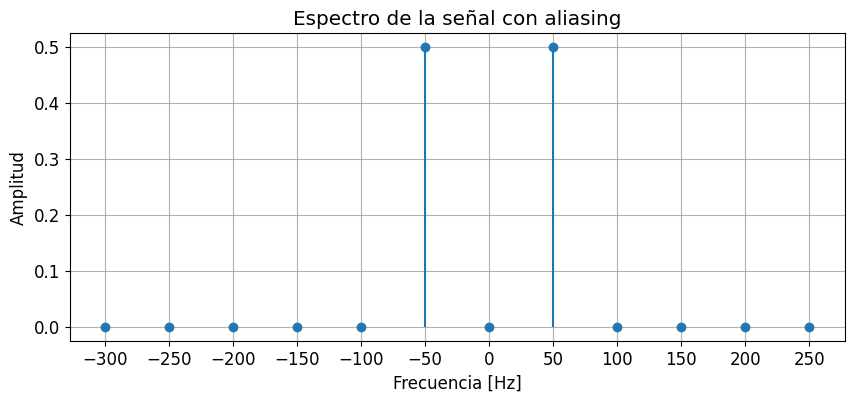

In [4]:
# Parámetros
Fs = 600             # Frecuencia de muestreo
F = 1250             # Frecuencia de la señal (1.25 kHz)
theta = np.pi / 3    # Fase
Nfft = 12

n = np.arange(-16, 14)
x_alias = np.cos(2*np.pi*F*n/Fs + theta)

# Visualización de la señal muestreada
fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(n, x_alias, basefmt=" ")
plt.setp(markerline, marker='o', markersize=6, color='red')
plt.setp(stemlines, color='blue', linewidth=1.5)
plt.setp(baseline, visible=False)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title("Señal muestreada con F = 1.25 kHz, Fs = 600 Hz")
plt.xlabel("Número de muestra [n]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# FFT
X_alias = fft(x_alias, Nfft)
freqs = fftfreq(Nfft, 1/Fs)
magnitude = np.abs(X_alias) / Nfft

plt.stem(freqs, magnitude, basefmt=" ")
plt.title("Espectro de la señal con aliasing")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.xticks(np.arange(int(freqs.min()), int(freqs.max())+50, 50))
plt.show()



**Discuta aquí los resultados obtenidos para el ejercicio 1.**

La frecuencia original de la señal **(1.25 kHz)** es mucho mayor que la mitad de la frecuencia de muestreo **(600 Hz)**, es decir, mayor que el límite de Nyquist **(Fs/2 = 300 Hz)**.

**Resultado:** Se produce un alias y la señal muestreada aparenta tener una frecuencia mucho más baja que la original. Esto también se refleja en el espectro: en lugar de ver un pico en 1.25 kHz, se observa uno más cercano a 50 Hz, como si la señal tuviera una frecuencia mucho menor.

# Ejercicio 2
Partiendo de la señal discreta en el tiempo obtenida en el ejercicio anterior:

1) Reconstruya la señal continua mediante interpolación sinc (reconstrucción ideal de Nyquist-Shannon).

2) Grafique en la misma figura la señal reconstruida y compárela con la señal original.

3) Discuta los resultados obtenidos.

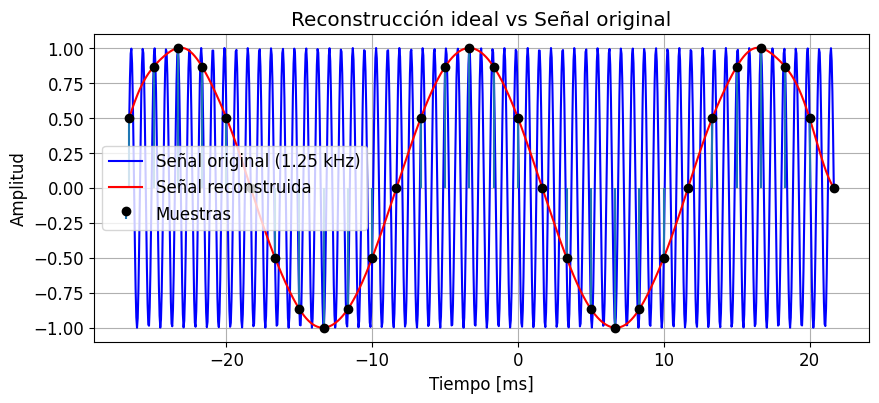

In [5]:
# Parámetros
Fs = 600             # Frecuencia de muestreo
F = 1250             # Frecuencia de la señal (1.25 kHz)
theta = np.pi / 3    # Fase
Nfft = 12

# Vector Tiempo ( simular tiempo continuo)
t_cont = np.linspace(n[0]/Fs, n[-1]/Fs, 1000)

# Interpolación sinc (interpolar valores intermedios)
import numpy as np

def interpolacion_sinc(muestras_discretas, indices_muestras, tiempo_evaluacion, frecuencia_muestreo):
    # Paso 1: Calcular la matriz de sinc.
    # En esta matriz cada elemento (i, j)
    # representa la muestra 'j' en el punto de tiempo 'i'.
    # (tiempo_evaluacion[:, None] * frecuencia_muestreo) - indices_muestras
    # utiliza 'broadcasting' para crear esta matriz de forma eficiente.
    # transforma el vectro fila tiempo_evaluacion  de 1000 valores en una matriz de [1000,1]
    matriz_sinc = np.sinc((tiempo_evaluacion[:, None] * frecuencia_muestreo) - indices_muestras)

    # Paso 2: Calcular el producto matricial.
    # Se multiplica la matriz_sinc por el vector de muestras discretas.
    # Este paso suma la influencia de cada muestra en cada punto de tiempo.
    # El resultado es equivalente a la funcion SUMATORIA de la interpolacion de Whittaker.
    senal_reconstruida = np.dot(matriz_sinc, muestras_discretas)

    return senal_reconstruida

x_reconstruida = interpolacion_sinc(x_alias, n, t_cont, Fs)

# Señal original (continua) de 1.25 kHz para comparar
x_orig = np.cos(2*np.pi*F*t_cont + theta)

# Gráfica
plt.plot(t_cont * 1000, x_orig, label='Señal original (1.25 kHz)', color='blue')
plt.plot(t_cont * 1000, x_reconstruida, label='Señal reconstruida', color='red')
plt.stem(n * 1000 / Fs, x_alias, label='Muestras',  markerfmt='ko', basefmt=" ")

plt.title("Reconstrucción ideal vs Señal original")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()



**Discuta aquí los resultados obtenidos para el ejercicio 2.**

La señal reconstruida **no coincide con la señal original de 1.25 kHz**. En cambio, coincide con la versión *aliaseada* (de menor frecuencia). Esto confirma que, una vez muestreada por debajo de Nyquist, la información original se pierde y solo se puede reconstruir el alias.



# Ejercicio 3
A partir de la señal \emph{muestreada en el tiempo} usada anteriormente:

1) Cuantifique las muestras utilizando un cuantizador uniforme de $L=8$ niveles (3 bits), y rango dinámico $[-1,\,1]$. Indique el paso de cuantización $(\Delta)$ y grafique la secuencia cuantificada.

2) Reconstruya la señal continua a partir de las muestras cuantificadasmediante interpolación sinc (reconstrucción ideal de Nyquist-Shannon) y grafique en la misma figura la señal reconstruida y las muestras cuantificadas.

3) Repita las incisos 1) y 2) para $L = 16, 32, 64$.

4) Discuta los resultados obtenidos.

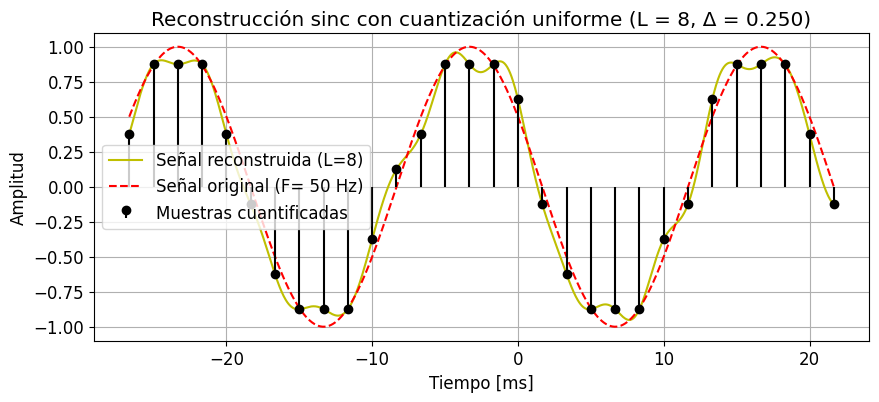

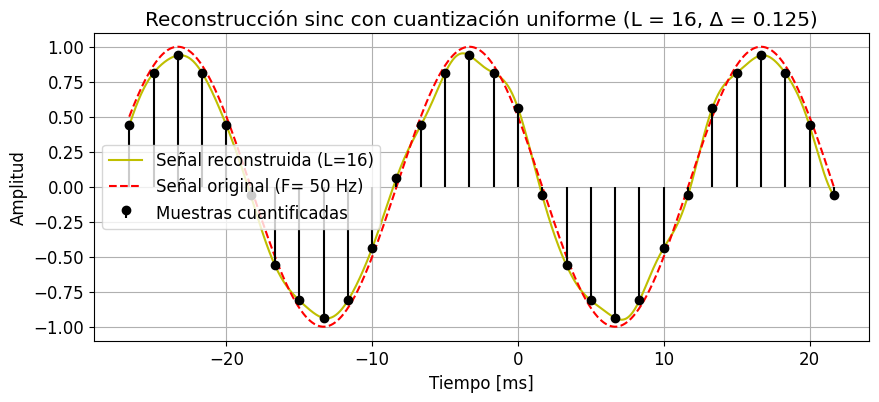

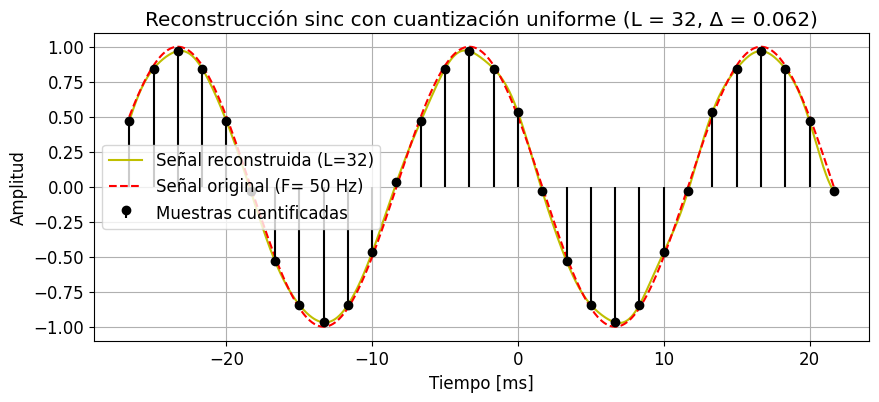

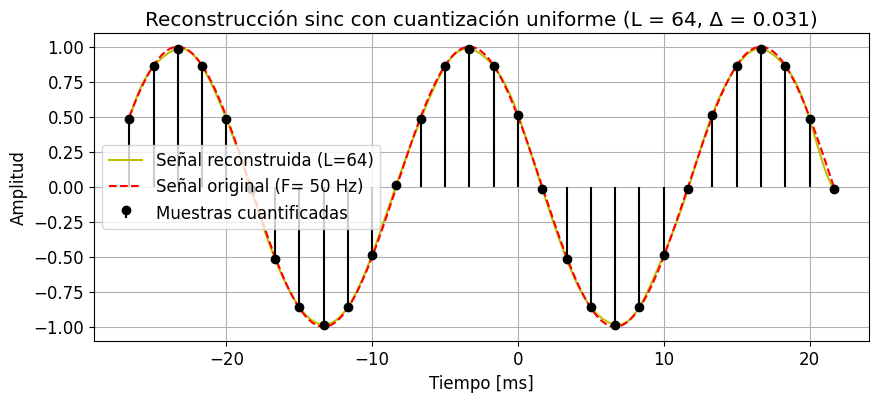

In [6]:
# Parámetros
Fs = 600             # Frecuencia de muestreo
F = 1250             # Frecuencia de la señal (1.25 kHz)
theta = np.pi / 3    # Fase
Nfft = 12



def cuantificar(x, L, x_min=-1, x_max=1):
    delta = (x_max - x_min) / L
    q_levels = np.linspace(x_min + delta/2, x_max - delta/2, L)
    idx = np.clip(((x - x_min) / delta).astype(int), 0, L-1)
    return q_levels[idx], delta

def reconstruccion_sinc(x_q, n, t, Fs):
    return interpolacion_sinc(x_q, n, t, Fs)

# Niveles de cuantización a evaluar
niveles = [8, 16, 32, 64]

# Tiempo continuo para reconstrucción
t_cont = np.linspace(n[0]/Fs, n[-1]/Fs, 1000)


for L in niveles:
    x_q, delta = cuantificar(x_alias, L)
    x_recon_q = reconstruccion_sinc(x_q, n, t_cont, Fs)
    X_alias_1 = np.cos(2*np.pi*F*t_cont + theta)
    X_original = np.cos(2*np.pi*50*t_cont + theta)


    plt.figure()
    plt.plot(t_cont * 1000, x_recon_q, label=f'Señal reconstruida (L={L})', color='y')
   ## plt.plot(t_cont * 1000, X_alias_1, label=f'Señal original (F={F} Hz)', color='blue', linestyle='--')  # Agregar la señal originalrecon_q, label=f'Señal reconstruida (L={L})', color='orange')
    plt.plot(t_cont * 1000, X_original, label=f'Señal original (F= 50 Hz)', color='red', linestyle='--')  # Agregar la señal originalrecon_q, label=f'Señal reconstruida (L={L})', color='orange')

    plt.stem(n * 1000 / Fs, x_q, linefmt='k-', markerfmt='ko', basefmt=" ", label='Muestras cuantificadas')
    plt.title(f"Reconstrucción sinc con cuantización uniforme (L = {L}, Δ = {delta:.3f})")
    plt.xlabel("Tiempo [ms]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.show()


**Discuta aquí los resultados obtenidos para el ejercicio 3.**

A medida que aumenta el **número de niveles (L)**, el paso de cuantización **Δ** se reduce, y la señal cuantificada se parece más a la original.

Con L=8 (3 bits), **hay errores notables de cuantización (dientes de sierra)**, especialmente cerca de los valores extremos.

Con L=64, la cuantización es mucho más precisa y la reconstrucción se aproxima bastante a la señal muestreada.

Sin embargo, **el aliasing introducido en el muestreo permanece**, y no se corrige con más niveles de cuantización. Solo mejora la precisión de la señal muestreada, no su frecuencia real.